In [1]:
import keras
import keras_tuner
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Reading the Given Training Datasets and Brute Random Split

Set the paths to the correct directory

In [2]:
x_train_dir = './resources/train_X.csv'
y_train_dir = './resources/train_y.csv'
x_test_dir = './resources/test_X.csv'


x_train_raw = pd.read_csv(x_train_dir)
x_train_raw = x_train_raw.drop(columns=[x_train_raw.columns[0]])

y_train_raw = pd.read_csv(y_train_dir)
y_train_raw = y_train_raw.drop(columns=[y_train_raw.columns[0]])

x_test = pd.read_csv(x_test_dir)
x_test = x_test.drop(columns=[x_test.columns[0]])

# Try random split and compare
x_train, x_val, y_train, y_val = train_test_split(x_train_raw, 
                                                  y_train_raw, 
                                                  test_size=0.3, 
                                                  random_state=42,
                                                  shuffle = True)


## Scaling

Scale the datasets with a scaler fitted only with training data to avoid data leakage. Used scaler in this case is StandardScaler()

In [3]:
x_scaler = StandardScaler()
x_scaler.fit(x_train)

x_train_scaled, x_val_scaled = x_scaler.transform(x_train), x_scaler.transform(x_val)

x_test_scaled = x_scaler.transform(x_test)

'''
scaling the y_train. Keep the scaler for 'descaling' the y_pred
y_pred_standard_unscaled = y_scaler_standard.inverse_transform(y_pred_standard_scaled.reshape(-1, 1))
'''
y_scaler = StandardScaler()
y_scaler.fit(y_train)

y_train_scaled, y_val_scaled = y_scaler.transform(y_train), y_scaler.transform(y_val)

# Linear Regression and Tree based model

As benchmarks, linear regression and XGBoost regressor will be used.

A common parameters are used for the XGBoost without tuning.

In [4]:
'''
linear regression
'''

lin_regr = linear_model.LinearRegression()
lin_regr.fit(x_train_scaled, y_train_scaled)

pred_val_lin_regr = lin_regr.predict(x_val_scaled)
# pred_val_lin_regr_unscaled = y_scaler.inverse_transform(pred_val_lin_regr.reshape(-1, 1))

# MSE_lin_regr = round(mean_squared_error(y_true=y_val, y_pred=pred_val_lin_regr_unscaled.flatten()),5)
MSE_lin_regr = round(mean_squared_error(y_true = y_val_scaled.flatten(), 
                                        y_pred = pred_val_lin_regr.flatten()),5)


'''
tree-based regression : XGBoost 
'''
xgb_regr = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='rmse',
    n_jobs=1 
)

xgb_regr.fit(x_train_scaled, y_train_scaled)

pred_val_xgb_regr = xgb_regr.predict(x_val_scaled)
# pred_val_xgb_regr_unscaled = y_scaler.inverse_transform(pred_val_xgb_regr.reshape(-1, 1))

'''
rescaling the y_pred
'''

# MSE_xgb_regr = round(mean_squared_error(y_true=y_val, y_pred=pred_val_xgb_regr_unscaled.flatten()),5)
MSE_xgb_regr = round(mean_squared_error(y_true = y_val_scaled.flatten(), 
                                        y_pred = pred_val_xgb_regr.flatten()),5)

print('Linear Regression: MSE = {} and RMSE: {}'.format(MSE_lin_regr, tf.sqrt(MSE_lin_regr)))
print('Tree based model (XGBoost): MSE = {} and RMSE = {}'.format(MSE_xgb_regr, tf.sqrt(MSE_xgb_regr)))


Linear Regression: MSE = 0.01562 and RMSE: 0.12497999519109726
Tree based model (XGBoost): MSE = 0.00462 and RMSE = 0.06797058135271072


# Neural Network Tuning

This subset will explain the neural network tuning procedures.

## Keras Hyperparameter Optimization

Using *keras_tuner*, following parameters will be assessed to deliver a optimized parameter for given architecture and dataset:

- Activation 
    - ['relu', 'tanh', 'sigmoid', 'elu', 'selu', 'swish', 'gelu']
- Dropout Rate
    - Min: 0
    - Max: 0.5
    - Step: 0.05
- Regularization
    - ['l1', 'l2']
- Regularization Rate
    - Min: 1e-5
    - Max: 1e-2
    - Sampling: log
- Number of hidden layers, including the unit for corresponding hidden layer
    - Min: 0
    - Max: 200
    - Step: 10
- Optimizer
    - ['adam', 'adamw', 'rmsprop', 'nadam']
- Learning Rate
    - Min: 1e-5
    - Max: 1e-2
    - Sampling: log

The performance indicator is the MSE for the validation loss. General settings for tuning follow as:

- max_trial = 100
- epochs = 100
- max. hidden layers = 3

In [5]:
def keras_hp_optimization(hp:keras_tuner.HyperParameters)->keras.Sequential:
    '''
    Perform hyperparameter tuning using keras_turner

    Parameters:
    -----------
    hp:keras_tuner.HyperParameters
        A set of different types of keras tuner hyperparameters, which can be sampled during the search.

    Returns: 
    ---------
    model: keras.Sequential
        The keras model built with the sequential api and the set of sampled hyperparameters in the current trial.
    '''

    # Sample of activation function
    curr_activation = hp.Choice('Activation', ['relu', 'tanh', 'sigmoid', 'elu', 'swish', 'gelu'])
    
    # Dropout rate for dropout layer
    # curr_dropout_rate = None
    curr_dropout_rate = hp.Float('Dropout_rate',
                                    min_value = 0.005,
                                    max_value = 0.5,
                                    step = 0.005)
    

    curr_regularization_value = hp.Float('regularization_value',
                                        min_value=1e-5,
                                        max_value=1e-2,
                                        sampling='log')
    
    regularizer = keras.regularizers.L2(curr_regularization_value)


    model = keras.Sequential()


    max_hidden_layers = 3
    keep_sampling_hidden_units = True
    nr_hidden_layer = 0

    while keep_sampling_hidden_units:
        
        # Input layer
        if nr_hidden_layer == 0:
            current_hidden_units = hp.Int('Units_hidden_layer{}'.format(nr_hidden_layer),
                                        min_value = 10,
                                        max_value = 200,
                                        step = 10)
            
        # Hidden layer
        else:
            current_hidden_units = hp.Int('Units_hidden_layer{}'.format(nr_hidden_layer),
                                        min_value = 10,
                                        max_value = 200,
                                        step = 10)
            
        
        if current_hidden_units != 0:
            model.add(keras.layers.Dense(units = current_hidden_units,
                                        activation = curr_activation,
                                        kernel_initializer = (keras.initializers.HeNormal() if curr_activation in ['relu', 'elu', 'swish', 'gelu'] else keras.initializers.GlorotNormal()),
                                        kernel_regularizer=regularizer
                                        ))

            model.add(keras.layers.Dropout(rate = curr_dropout_rate))

        if current_hidden_units == 0 or nr_hidden_layer == max_hidden_layers-1:
            keep_sampling_hidden_units = False
        
        nr_hidden_layer += 1
    
    # Output layer
    model.add(keras.layers.Dense(units = 1,
                                activation = 'linear'))
    

    # Sample of opotimizer
    curr_optimizer = hp.Choice('optimizer', ['adam', 'adamw', 'rmsprop', 'nadam'])

    # Learning rate
    curr_learning_rate = hp.Float('learning_rate',
                                     min_value=1e-5,
                                     max_value=1e-2,
                                     sampling='log')
    
    # Setting the optimizer
    if curr_optimizer == 'adam':
        optimizer_t = keras.optimizers.Adam(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'adamw':
        optimizer_t = keras.optimizers.AdamW(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'rmsprop':
        optimizer_t = keras.optimizers.RMSprop(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'nadam':
        optimizer_t = keras.optimizers.Nadam(learning_rate = curr_learning_rate)
    

    model.compile(optimizer = optimizer_t, loss = 'mse')
    
    return model

## Perform Tuning

Two tuning algorithms will be tested to get the best hyperparameters. The two algorithms are: **Random Search** and **BayesianOptimization**

In [6]:
# Setting for early stop
es_callback = keras.callbacks.EarlyStopping(monitor='val_loss',
                                            patience=5,
                                            verbose=1,
                                            mode='min')


# # Turner for RandomSearch
# tuner_random = keras_tuner.RandomSearch(keras_hp_optimization,
#                                         objective = 'val_loss',
#                                         max_trials = 100,
#                                         directory = './temp/temp_random/checkpoint',
#                                         overwrite = True)

# tuner_random.search(x_train_scaled, 
#              y_train_scaled, 
#              epochs = 100, 
#              validation_data = (x_val_scaled, y_val_scaled), 
#              callbacks = [es_callback])


# Tuner for BayesianOptimization
tuner_bayes = keras_tuner.BayesianOptimization(keras_hp_optimization,
                                                objective = 'val_loss',
                                                max_trials = 100,
                                                directory = './temp/temp_bayes/checkpoint',
                                                overwrite = True)

tuner_bayes.search(x_train_scaled, 
             y_train_scaled, 
             epochs = 100, 
             validation_data = (x_val_scaled, y_val_scaled), 
             callbacks = [es_callback])


# # Documenting the parameters of best model for both tuning algorithms
# model_json_random = tuner_random.get_best_models()[0].to_json()
# with open(os.path.join('./temp/temp_random', 'best_model_random.json'), 'w') as json_file:
#     json_file.write(model_json_random)

model_json_bayes = tuner_bayes.get_best_models()[0].to_json()
with open(os.path.join('./temp/temp_bayes', 'best_model_bayes.json'), 'w') as json_file:
    json_file.write(model_json_bayes)



# # Getting the losses from model of both tuning algorithms
# best_trial_random = tuner_random.oracle.get_best_trials(num_trials=1)[0]
# best_val_loss_random = best_trial_random.score

best_trial_bayes = tuner_bayes.oracle.get_best_trials(num_trials=1)[0]
best_val_loss_bayes = best_trial_bayes.score



# print("Best val_loss_random:", best_val_loss_random)
# print('Best random hyperparameters: {}'.format(tuner_random.get_best_hyperparameters()[0].values))
print("Best val_loss_bayes:", best_val_loss_bayes)
print('Best bayes hyperparameters: {}'.format(tuner_bayes.get_best_hyperparameters()[0].values))

Trial 100 Complete [00h 00m 02s]
val_loss: 0.10500771552324295

Best val_loss So Far: 0.0017810458084568381
Total elapsed time: 00h 07m 11s
Best val_loss_bayes: 0.0017810458084568381
Best bayes hyperparameters: {'Activation': 'relu', 'Dropout_rate': 0.005, 'regularization_value': 1e-05, 'Units_hidden_layer0': 10, 'Units_hidden_layer1': 10, 'Units_hidden_layer2': 120, 'optimizer': 'nadam', 'learning_rate': 0.01}


/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 19 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Summary from Tuning

both random and bayes tuner delivered some similarities. Those are:

- 'gelu' as activation delivered supposedly best result
- The combination of dropout and l2-regularizator with no major different rate


Final decision will be met, after doing trainig and comapring the validation loss for both purposed hyperparameters.

# Neural Network

The previous section will give the best hyperparameter for the model architecture and training dataset. In this section, several neural networks with these hyperparameters will be compared.

## Functions to Build and Start Training

Necessary functions necessary to build the neural network

In [7]:
def training(model:keras.Model,
             x_batch_data:tf.Tensor,
             y_batch_data:tf.Tensor,
             optimizer:None = None)->tf.Tensor:
    '''
    Perform model trainig. Implementing Backpropagation and weight updates based on training loss.

    Parameters:
    -----------
    model:keras.Model
        The feedforward neural network.
    x_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    y_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    optimizer: None
        The optimizer used during the training process. Since during testing time, we do not need it, the parameters has the input type None.
        During training time, parameter would be of the type tf.keras.optimizers.Optimizer.

    Returns: 
    ---------
    train_loss: Numpy
        the loss during training   
    train_r2: Numpy
        the r2 score during training
    '''
    
    with tf.GradientTape() as tape:
        pred = model(x_batch_data, training=True)
        train_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(pred,axis=-1),
                                         y_true = tf.squeeze(y_batch_data,axis=-1))
        
        r2_metric = tf.keras.metrics.R2Score()
        r2_metric.update_state(y_batch_data, pred)
        train_r2 = r2_metric.result()
    
    # Weight updates for backward pass
    gradients = tape.gradient(train_loss, model.trainable_variables) # compute weight updates for backward pass
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))#apply computed gradients
    
    return train_loss, train_r2

def validation(model:keras.Model,
               x_batch_data:tf.Tensor,
               y_batch_data:tf.Tensor)->tf.Tensor:
    '''
    Perform model trainig. Implementing Backpropagation and weight updates based on training loss.

    Parameters:
    -----------
    model:keras.Model
        The feedforward neural network.
    x_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    y_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.

    Returns: 
    ---------
    val_loss: Numpy
        the loss during validation
    val_r2: Numpy
        the r2 score during validation
    '''
    
    pred = model(x_batch_data)
    val_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(pred,axis=-1),
                                   y_true = tf.squeeze(y_batch_data,axis=-1))
    
    
    r2_metric = tf.keras.metrics.R2Score()
    r2_metric.update_state(y_batch_data, pred)
    val_r2 = r2_metric.result()
    
    
    return val_loss, val_r2


def build_tf_model(n_features:int,
                   list_units:list,
                   activation:str,
                   dropout_rate:float,
                   regularization_rate:float = None)->keras.Model:
    ''''
    Cerate a feedforward neural network using Dense layers in keras.

    Parameters:
    -----------
    nr_features:int
        The number of predictor variables, which is important for the initialization of the weights in the first hidden layer.
    list_units:list
        A list containing the number of hidden units per layer. The length of this list determines the number of hidden layer of the network.
    activation: str
        The nonlinearity to apply in each hidden layer.
    dropout_rate: float
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    regularization: float
        Including type of regularizer and the corresponding strength 

    Returns:
    --------
    tf_model: tf.keras.Model
        The tensorflow feedforwar neural network.
    '''

    # Input layer
    input_layer = keras.layers.Input(shape=n_features)
    hidden_layers = input_layer

    # Iteration for hidden layers
    for unit in list_units:
        hidden_layers = keras.layers.Dense(units=unit, 
                                            activation=activation,
                                            # Different activation will be assigned to suitable initializer to improve performance
                                            kernel_initializer = keras.initializers.HeNormal() if activation in ['relu', 'elu', 'swish', 'gelu'] else keras.initializers.GlorotNormal(),
                                            kernel_regularizer = tf.keras.regularizers.L2(regularization_rate) if regularization_rate is not None else None
                                            )(hidden_layers)
            
        hidden_layers = keras.layers.Dropout(rate=dropout_rate)(hidden_layers)

    # Output layer
    output_layer = keras.layers.Dense(units = 1,
                                      activation = 'linear'
                                      )(hidden_layers) 

    tf_model = keras.Model(inputs = input_layer,
                           outputs = output_layer) 

    return tf_model

## Reading Test Dataset and Batching Training Datset for non KFold

For KFold, batching will be procced after the random split. For Neural Network without KFold, the dataset is split here.

At the same time, also preparing the test dataset.

In [8]:
#Splitting train and test dataset into mini-batches:
batch_size=32

tf_train_scaled = tf.data.Dataset.from_tensor_slices((x_train_scaled,y_train_scaled)).batch(batch_size)
tf_val_scaled = tf.data.Dataset.from_tensor_slices((x_val_scaled,y_val_scaled)).batch(batch_size)

## Untuned Neural Network

As another benchmark, a randomly assigned parameters/ untuned nueral network is consructed. The model will be trained over 100 epochs with following hyperparameters:
- list_units = [100, 50, 25]
- dropout_rate = 0.3
- activation = 'relu'
- optimizer = 'adam'
- learning_rate=0.001

In [9]:
# Tuning n_units(hidden layer), dropout_rate, and activation function
tf_model = build_tf_model(n_features = (x_train_scaled.shape[1], ),
                          list_units = [100, 50, 25],
                          dropout_rate = 0.001,
                          activation = 'relu')

# Tuning learning rate, optimizer and epochs
tf_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
n_epochs = 100

train_loss_untuned = []
train_r2_untuned = []
val_loss_untuned = []
val_r2_untuned = []

# Early stoppping criterium
patience = 5
wait = 0
# We would like to minimize our loss, thus we set the initial best value to inf+
best = float('inf')

for epoch in range(n_epochs):
    epoch_train_loss = []
    epoch_val_loss = []
    epoch_train_r2 = []
    epoch_val_r2 = []

    # Training
    for (x_batch_train,y_batch_train) in tf_train_scaled:
        curr_train_loss, curr_train_r2 = training(model = tf_model,
                              x_batch_data = x_batch_train,
                              y_batch_data = y_batch_train,
                              optimizer = tf_optimizer)

        epoch_train_loss.append(curr_train_loss.numpy())
        epoch_train_r2.append(curr_train_r2.numpy())

    train_loss_untuned.append(np.mean(epoch_train_loss))
    train_r2_untuned.append(np.mean(epoch_train_r2))

    # Validation 
    for (x_batch_val,y_batch_val) in tf_val_scaled:
        curr_val_loss, curr_val_r2 = validation(model = tf_model,
                                                    x_batch_data = x_batch_val,
                                                    y_batch_data = y_batch_val)

        epoch_val_loss.append(curr_val_loss.numpy())
        epoch_val_r2.append(curr_val_r2.numpy())

    epoch_val_loss = np.mean(epoch_val_loss)
    val_loss_untuned.append(epoch_val_loss)
    val_r2_untuned.append(np.mean(epoch_val_r2))

    #Early stopping callback:
    if epoch_val_loss < best:
        best = epoch_val_loss
        wait = 0
    else:
        wait += 1
        
    if wait >= patience:
        break


pred = tf_model(x_test_scaled)
pred_unscaled = y_scaler.inverse_transform(pred)


try:
   pd.DataFrame(pred_unscaled).to_csv('./temp/export/untuned_NN.csv')  
except:
  os.mkdir('./temp/export')
  os.mkdir('./temp/models')
  pd.DataFrame(pred_unscaled).to_csv('./temp/export/untuned_NN.csv')

# tf_model.save('./temp/models/untuned_NN.keras')
print('MSE: training_loss is {} and validation_loss is {}'.format(min(train_loss_untuned), min(val_loss_untuned)))
print('RMSE: training_loss is {} and validation_loss is {}'.format((tf.sqrt(min(train_loss_untuned))), tf.sqrt(min(val_loss_untuned))))

2025-05-30 18:35:55.329348: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-30 18:35:55.384844: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-30 18:35:55.981346: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-30 18:35:57.125226: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-30 18:35:59.420423: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-30 18:36:03.963458: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


MSE: training_loss is 0.006819568108767271 and validation_loss is 0.00921514630317688
RMSE: training_loss is 0.08258067816495895 and validation_loss is 0.09599555283784866


## Tuned Neural Network

### Tuned NN basic

In [10]:
# Tuning n_units(hidden layer), dropout_rate, and activation function
tf_model = build_tf_model(n_features = (x_train_scaled.shape[1], ),
                          list_units = [10, 10, 120],
                          dropout_rate = 0.005,
                          regularization_rate=  1e-05,
                          activation = 'relu')

# Tuning learning rate, optimizer and epochs
tf_optimizer = keras.optimizers.Nadam(learning_rate=0.01)
n_epochs = 100

train_loss_tuned = []
val_loss_tuned = []

train_r2_tuned = []
val_r2_tuned = []

# Early stoppping criterium
patience = 5
wait = 0
# We would like to minimize our loss, thus we set the initial best value to inf+
best = float('inf')

for epoch in range(n_epochs):
    epoch_train_loss = []
    epoch_val_loss = []
    epoch_train_r2 = []
    epoch_val_r2 = []

    # Training
    for (x_batch_train,y_batch_train) in tf_train_scaled:
        curr_train_loss, curr_train_r2 = training(model = tf_model,
                                                  x_batch_data = x_batch_train,
                                                  y_batch_data = y_batch_train,
                                                  optimizer = tf_optimizer)

        epoch_train_loss.append(curr_train_loss.numpy())
        epoch_train_r2.append(curr_train_r2.numpy())

    train_loss_tuned.append(np.mean(epoch_train_loss))
    train_r2_tuned.append(np.mean(epoch_train_r2))

    # Validation 
    for (x_batch_val,y_batch_val) in tf_val_scaled:
        curr_val_loss, curr_val_r2 = validation(model = tf_model,
                                                    x_batch_data = x_batch_val,
                                                    y_batch_data = y_batch_val)

        epoch_val_loss.append(curr_val_loss.numpy())
        epoch_val_r2.append(curr_val_r2.numpy())

    epoch_val_loss = np.mean(epoch_val_loss)
    val_loss_tuned.append(epoch_val_loss)
    val_r2_tuned.append(np.mean(epoch_val_r2))

    #Early stopping callback:
    if epoch_val_loss < best:
        best = epoch_val_loss
        wait = 0
    else:
        wait += 1
        
    if wait >= patience:
        break



pred = tf_model(x_test_scaled)
pred_unscaled = y_scaler.inverse_transform(pred)
pd.DataFrame(pred_unscaled).to_csv('./temp/export/tuned_NN.csv')  

# tf_model.save('./temp/models/untuned_NN.keras')
print('MSE: training_loss is {} and validation_loss is {}'.format(min(train_loss_tuned), min(val_loss_tuned)))
print('RMSE: training_loss is {} and validation_loss is {}'.format(tf.sqrt(min(train_loss_tuned)), tf.sqrt(min(val_loss_tuned))))

2025-05-30 18:37:35.784254: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


MSE: training_loss is 0.0034138422925025225 and validation_loss is 0.0020990115590393543
RMSE: training_loss is 0.058428093791007996 and validation_loss is 0.04581497237086296


### Tuned NN with k-Fold

In [ ]:
# Batching and KFold parameters
batch_size = 32
n_split = 5
kf = KFold(n_splits= n_split, shuffle= True, random_state= 42)

# Model config.
n_epochs = 100
patience = 5


# Data processing
x_train_raw = np.array(x_train_raw)
y_train_raw = np.array(y_train_raw)
sum_train_loss_tuned_kfold = []
sum_val_loss_tuned_kfold = []

sum_train_r2_tuned_kfold = []
sum_val_r2_tuned_kfold = []

sum_pred_tuned_kfold = []

# KFold Cross Validation
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train_raw)):
    x_train, x_val = x_train_raw[train_idx], x_train_raw[val_idx]
    y_train, y_val = y_train_raw[train_idx], y_train_raw[val_idx]

    # Scale the data
    x_scaler = StandardScaler()
    x_scaler.fit(x_train)
    x_train_scaled, x_val_scaled = x_scaler.transform(x_train), x_scaler.transform(x_val)
    x_test_scaled = x_scaler.transform(x_test)

    y_scaler = StandardScaler()
    y_scaler.fit(y_train)
    y_train_scaled, y_val_scaled = y_scaler.transform(y_train), y_scaler.transform(y_val)

    # Transform as tf.dataset
    tf_train_rescaled = tf.data.Dataset.from_tensor_slices((x_train_scaled,y_train_scaled)).batch(batch_size)
    tf_val_rescaled = tf.data.Dataset.from_tensor_slices((x_val_scaled,y_val_scaled)).batch(batch_size)

    
    # Tuning n_units(hidden layer), dropout_rate, and activation function
    tf_model = build_tf_model(n_features = (x_train_scaled.shape[1], ),
                            list_units = [10, 10, 120],
                            dropout_rate = 0.005,
                            regularization_rate=  1e-05,
                            activation = 'relu')

    # Tuning learning rate, optimizer and epochs
    tf_optimizer = keras.optimizers.Nadam(learning_rate=0.01)
    best = float('inf')
    wait = 0

    train_loss_fold = []
    train_r2_fold = []
    val_loss_fold = []
    val_r2_fold = []

    for epoch in range(n_epochs):
        epoch_train_loss = []
        epoch_val_loss = []
        epoch_train_r2 = []
        epoch_val_r2 = []

        # Training
        for (x_batch_train,y_batch_train) in tf_train_rescaled:
            curr_train_loss, curr_train_r2 = training(model = tf_model,
                                x_batch_data = x_batch_train,
                                y_batch_data = y_batch_train,
                                optimizer = tf_optimizer)

            epoch_train_loss.append(curr_train_loss.numpy())
            epoch_train_r2.append(curr_train_r2.numpy())

        train_loss_fold.append(np.mean(epoch_train_loss))
        train_r2_fold.append(np.mean(epoch_train_r2))

        # Validation 

        for (x_batch_val,y_batch_val) in tf_val_scaled:
            curr_val_loss, curr_val_r2 = validation(model = tf_model,
                                                        x_batch_data = x_batch_val,
                                                        y_batch_data = y_batch_val)

            epoch_val_loss.append(curr_val_loss.numpy())
            epoch_val_r2.append(curr_val_r2.numpy())

        mean_epoch_val_loss = np.mean(epoch_val_loss)
        val_loss_fold.append(mean_epoch_val_loss)
        val_r2_fold.append(np.mean(epoch_val_r2))

        #Early stopping callback:
        if mean_epoch_val_loss < best:
            best = mean_epoch_val_loss
            wait = 0
        else:
            wait += 1
            
        if wait >= patience:
            break

    pred = tf_model(x_test_scaled)
    pred_unscaled = y_scaler.inverse_transform(pred)

    sum_pred_tuned_kfold.append(pred_unscaled)
    sum_train_loss_tuned_kfold.append(train_loss_fold)
    sum_val_loss_tuned_kfold.append(val_loss_fold)

    sum_train_r2_tuned_kfold.append(train_r2_fold)
    sum_val_r2_tuned_kfold.append(val_r2_fold)

    

max_epochs = max(len(iter) for iter in sum_train_loss_tuned_kfold)

mean_pred_tuned_kfold = np.mean(sum_pred_tuned_kfold, axis=0)

pd.DataFrame(mean_pred_tuned_kfold).to_csv('./temp/export/tuned_kfold_NN.csv')  


for i in range(len(sum_train_loss_tuned_kfold)):
    sum_train_loss_tuned_kfold[i] += [np.nan] * (max_epochs - len(sum_train_loss_tuned_kfold[i]))
    sum_val_loss_tuned_kfold[i] += [np.nan] * (max_epochs - len(sum_val_loss_tuned_kfold[i]))

    sum_train_r2_tuned_kfold[i] += [np.nan] * (max_epochs - len(sum_train_r2_tuned_kfold[i]))
    sum_val_r2_tuned_kfold[i] += [np.nan] * (max_epochs - len(sum_val_r2_tuned_kfold[i]))



mean_train_loss_tuned_kfold = np.nanmean(np.array(sum_train_loss_tuned_kfold), axis=0)
mean_val_loss_tuned_kfold = np.nanmean(np.array(sum_val_loss_tuned_kfold), axis=0)

mean_train_r2_loss_tuned_kfold = np.nanmean(np.array(sum_train_r2_tuned_kfold), axis=0)
mean_val_r2_loss_tuned_kfold = np.nanmean(np.array(sum_val_r2_tuned_kfold), axis=0)

# tf_model.save('./temp/models/tuned_NN_kFold.keras')
print('MSE: training_loss is {} and validation_loss is {}'.format(min(mean_train_loss_tuned_kfold), min(mean_val_loss_tuned_kfold)))
print('RMSE: training_loss is {} and validation_loss is {}'.format(tf.sqrt(min(mean_train_loss_tuned_kfold)), tf.sqrt(min(mean_val_loss_tuned_kfold))))



/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
2025-05-30 18:55:22.699597: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-p

MSE: training_loss is 0.0023548738099634647 and validation_loss is 0.0014776327880099416
RMSE: training_loss is 0.0485270420483617 and validation_loss is 0.03843998943821319


#  Visualization

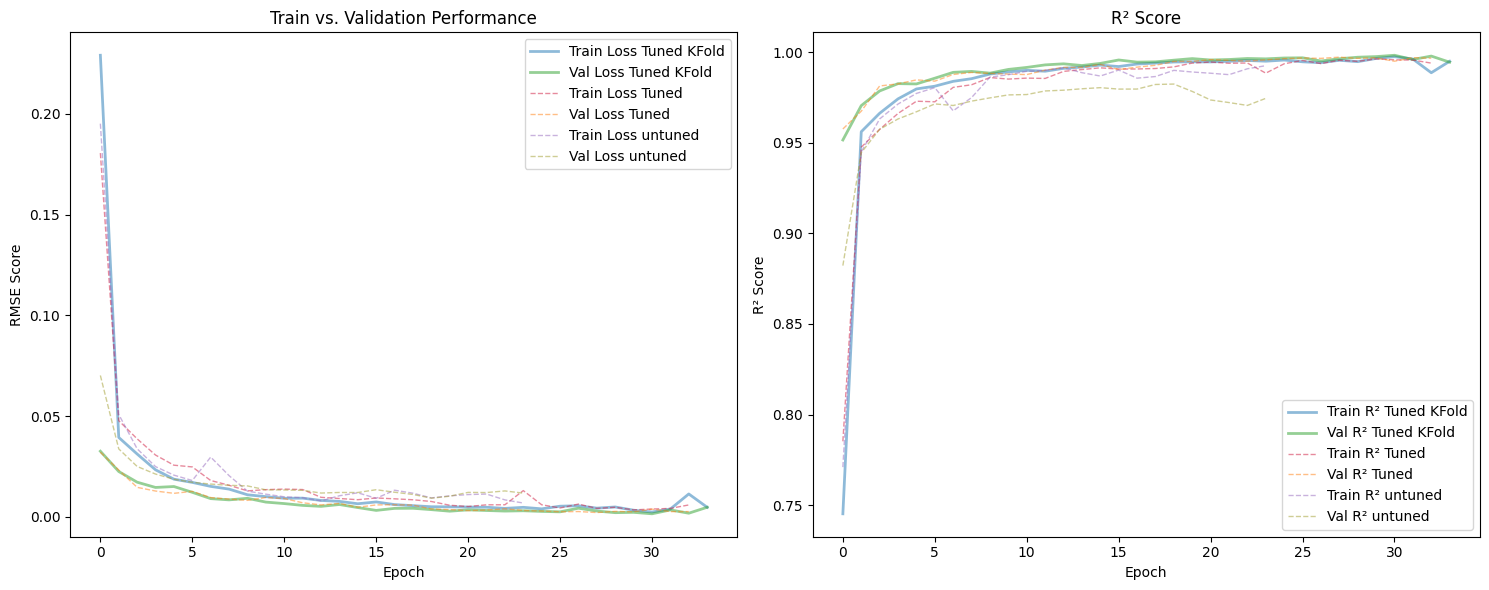

                          Model      MSE     RMSE       R²
              Linear Regression 0.015620 0.124980        -
                        XGBoost 0.004620 0.067971        -
       Neural Network (Untuned) 0.009215 0.095996 0.982360
         Neural Network (Tuned) 0.002099 0.045815 0.997206
Neural Network (Tuned + K-Fold) 0.001478 0.038440 0.998258


In [ ]:
# Visualize the model performance:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RMSE vs. Epochs
ax1.plot(mean_train_loss_tuned_kfold, label='Train Loss Tuned KFold', linewidth=2, color='#1f77b4', alpha=0.5)
ax1.plot(mean_val_loss_tuned_kfold, label='Val Loss Tuned KFold', linewidth=2, color='#2ca02c', alpha=0.5)

ax1.plot(train_loss_tuned, label='Train Loss Tuned', linestyle='--', linewidth=1, color="#cf173c", alpha=0.5)
ax1.plot(val_loss_tuned, label='Val Loss Tuned', linestyle='--', linewidth=1, color='#ff7f0e', alpha=0.5)

ax1.plot(train_loss_untuned, label='Train Loss untuned', linestyle='--', linewidth=1, color="#9467bd", alpha=0.5)
ax1.plot(val_loss_untuned, label='Val Loss untuned', linestyle='--', linewidth=1, color="#a09c2c", alpha=0.5)
ax1.set_ylabel('RMSE Score')
ax1.set_xlabel('Epoch')
ax1.set_title('Train vs. Validation Performance')
ax1.legend()


# R² vs. Epochs
ax2.plot(mean_train_r2_loss_tuned_kfold, label='Train R² Tuned KFold', linewidth=2, color='#1f77b4', alpha=0.5)
ax2.plot(mean_val_r2_loss_tuned_kfold, label='Val R² Tuned KFold', linewidth=2, color='#2ca02c', alpha=0.5)

ax2.plot(train_r2_tuned, label='Train R² Tuned', linestyle='--', linewidth=1, color="#cf173c", alpha=0.5)
ax2.plot(val_r2_tuned, label='Val R² Tuned', linestyle='--', linewidth=1, color='#ff7f0e', alpha=0.5)

ax2.plot(train_r2_untuned, label='Train R² untuned', linestyle='--', linewidth=1, color="#9467bd", alpha=0.5)
ax2.plot(val_r2_untuned, label='Val R² untuned', linestyle='--', linewidth=1, color="#a09c2c", alpha=0.5)

ax2.set_ylabel('R² Score')
ax2.set_xlabel('Epoch')
ax2.set_title('R² Score')
ax2.legend()

plt.tight_layout()
plt.show()
plt.close()



comparison_data = {
    'Model': [
        'Linear Regression',
        'XGBoost',
        'Neural Network (Untuned)',
        'Neural Network (Tuned)',
        'Neural Network (Tuned + K-Fold)'
    ],
    'MSE': [
        MSE_lin_regr,
        MSE_xgb_regr,
        min(val_loss_untuned),
        min(val_loss_tuned),
        min(mean_val_loss_tuned_kfold)
    ],
    'RMSE': [
        float(tf.sqrt(MSE_lin_regr)),
        float(tf.sqrt(MSE_xgb_regr)),
        float(tf.sqrt(min(val_loss_untuned))),
        float(tf.sqrt(min(val_loss_tuned))),
        float(tf.sqrt(min(mean_val_loss_tuned_kfold)))
    ],
    'R²': [
        f"-",
        f"-",
        f"{max(val_r2_untuned):.6f}" if 'val_r2_untuned' in globals() else 'N/A',
        f"{max(val_r2_tuned):.6f}",
        f"{max(mean_val_r2_loss_tuned_kfold):.6f}"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Why the architecture is suitable for the task?

#### The [10, 10, 120] bottleneck architecture is well-suited for this 19-feature regression task because the narrow initial layers force the model to learn only the most relevant feature combinations, reducing the risk of overfitting. Expanding to 120 units in the final hidden layer enables the neural network to capture more complex, non-linear relationhsips needed for accurate prediction. The tuning process shows that only minimal regularization is required, as evidenced by high R² scores and closely aligned training and validation losses, indicating strong generalization without excessive model complexity.

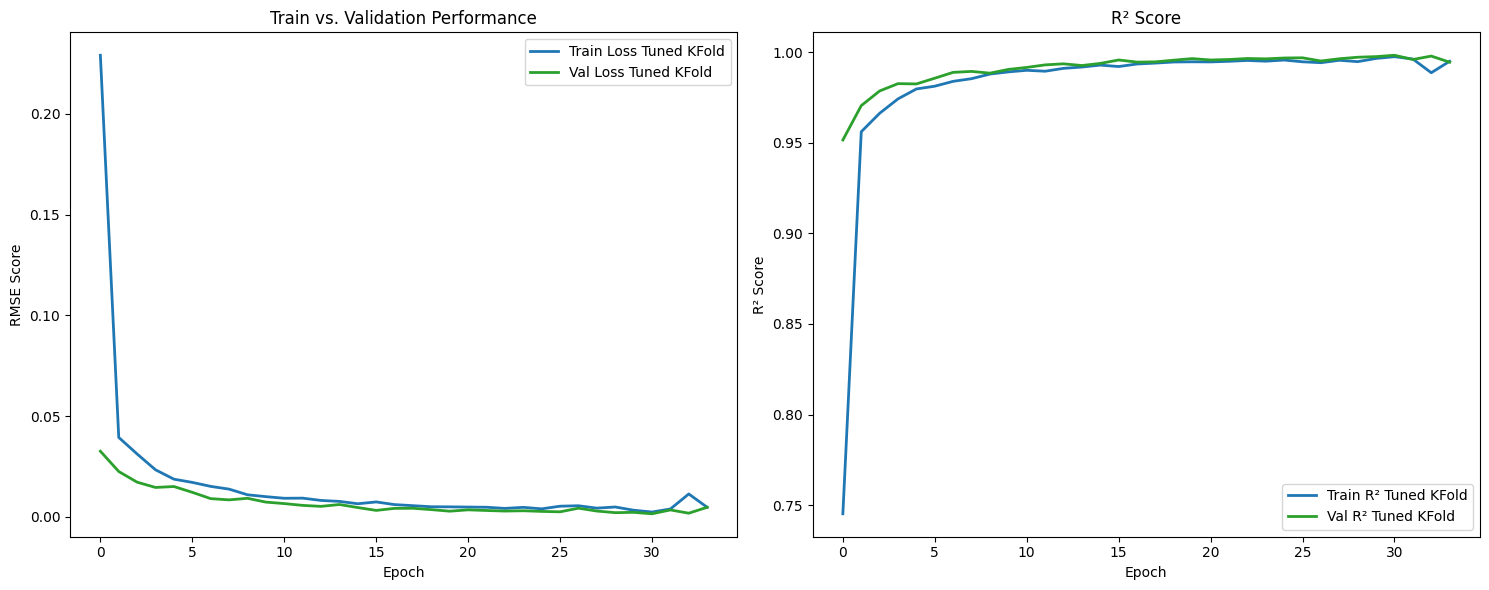

Best Model: Neural Network (Tuned + K-Fold)
MSE: 0.03843998943821319
R²: 0.998258
Hyperparameters Used In Tuned-K-Fold NN
Architecture: [10, 10, 120]
Activation Function: relu
Dropout Rate: 0.005
L2 Regularization: 1e-05
Optimizer: Nadam
Learning Rate: 0.01
Batch Size: 32
K-Fold Splits: 5
Max Epochs: 100
Early Stopping Patience: 5


In [ ]:
# Visualize the model performance:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RMSE vs. Epochs
ax1.plot(mean_train_loss_tuned_kfold, label='Train Loss Tuned KFold', linewidth=2, color='#1f77b4')
ax1.plot(mean_val_loss_tuned_kfold, label='Val Loss Tuned KFold', linewidth=2, color='#2ca02c')

ax1.set_ylabel('RMSE Score')
ax1.set_xlabel('Epoch')
ax1.set_title('Train vs. Validation Performance')
ax1.legend()


# R² vs. Epochs
ax2.plot(mean_train_r2_loss_tuned_kfold, label='Train R² Tuned KFold', linewidth=2, color='#1f77b4')
ax2.plot(mean_val_r2_loss_tuned_kfold, label='Val R² Tuned KFold', linewidth=2, color='#2ca02c')

ax2.set_ylabel('R² Score')
ax2.set_xlabel('Epoch')
ax2.set_title('R² Score')
ax2.legend()

plt.tight_layout()
plt.show()
plt.close()

hyperparameters = {
    'list_units': [10, 10, 120],
    'dropout_rate': 0.005,
    'regularization_rate': 1e-05,
    'activation': 'relu',
    'optimizer': 'Nadam',
    'learning_rate': 0.01,
    'batch_size': batch_size,
    'n_splits': n_split,
    'n_epochs': n_epochs,
    'patience': patience
}

print(f"Best Model: Neural Network (Tuned + K-Fold)")
print(f"MSE: {float(tf.sqrt(min(mean_val_loss_tuned_kfold)))}")
print(f"R²: {max(mean_val_r2_loss_tuned_kfold):.6f}")

print("=" * 80)
print("Hyperparameters Used In Tuned-K-Fold NN")
print("=" * 80)
print(f"Architecture: {hyperparameters['list_units']}")
print(f"Activation Function: {hyperparameters['activation']}")
print(f"Dropout Rate: {hyperparameters['dropout_rate']}")
print(f"L2 Regularization: {hyperparameters['regularization_rate']}")
print(f"Optimizer: {hyperparameters['optimizer']}")
print(f"Learning Rate: {hyperparameters['learning_rate']}")
print(f"Batch Size: {hyperparameters['batch_size']}")
print(f"K-Fold Splits: {hyperparameters['n_splits']}")
print(f"Max Epochs: {hyperparameters['n_epochs']}")
print(f"Early Stopping Patience: {hyperparameters['patience']}")


#

# Model interpretation based on plot

#### The Model improved significantly from the early epochs, followed by stable learning progress, with the loss and R2-Score remain closly aligned to each other until early stopped is triggered during both training and validation. The plot and evaluation parameter show no sign of overfitting, good generalization and optimal hyperparameter tuning.